<a href="https://colab.research.google.com/github/fecheromero/PNL_tps_Romero_Federico/blob/main/Desafio_4_Romero_Federico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
# Desafio 4, LSTM Bot QA

### Datos
El objetivo es utilizar datos disponibles del challenge ConvAI2 (Conversational Intelligence Challenge 2) de conversaciones en inglés. Se construirá un BOT para responder a preguntas del usuario (QA).\
[LINK](http://convai.io/data/)

In [ ]:
!pip install --upgrade --no-cache-dir gdown --quiet

In [ ]:
import re

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.utils import pad_sequences
from keras.models import Sequential
from keras.layers import Activation, Dropout, Dense
from keras.layers import Flatten, LSTM, SimpleRNN
from keras.models import Model
from tensorflow.keras.layers import Embedding
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Input

In [ ]:
# Descargar la carpeta de dataset
import os
import gdown
if os.access('data_volunteers.json', os.F_OK) is False:
    url = 'https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN&export=download'
    output = 'data_volunteers.json'
    gdown.download(url, output, quiet=False)
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [ ]:
# dataset_file
import json

text_file = "data_volunteers.json"
with open(text_file) as f:
    data = json.load(f) # la variable data será un diccionario



In [ ]:
# Observar los campos disponibles en cada linea del dataset
data[0].keys()

dict_keys(['dialog', 'start_time', 'end_time', 'bot_profile', 'user_profile', 'eval_score', 'profile_match', 'participant1_id', 'participant2_id'])

### Observar un elemento completo del dataset

In [ ]:
import json

# Mostrar el primer elemento completo de la lista 'data'
print("Primer elemento completo de 'data':")
print(json.dumps(data[0], indent=2))


Primer elemento completo de 'data':
{
  "dialog": [
    {
      "id": 0,
      "sender": "participant1",
      "text": "hi there",
      "evaluation_score": null,
      "sender_class": "Human"
    }
  ],
  "start_time": "2018-10-29 03:32:08.296000",
  "end_time": "2018-10-29 03:32:08.296000",
  "bot_profile": [
    "i like to talk but people have a hard time understanding.",
    "i like to look at blocks and sing about letters.",
    "i like to eat chocolate candy.",
    "when i grow up i want to be a dog."
  ],
  "user_profile": [
    "i am a clean eater.",
    "my parents were both very athletic.",
    "i love running and preparing for marathons.",
    "i am a cancer survivor."
  ],
  "eval_score": null,
  "profile_match": "",
  "participant1_id": {
    "class": "User",
    "user_id": "User 00172"
  },
  "participant2_id": {
    "class": "Bot",
    "user_id": "Bot 004"
  }
}


### Observar los primeros turnos de diálogo del primer elemento

In [ ]:
chat_in = []
chat_out = []

input_sentences = []
output_sentences = []
output_sentences_inputs = []
max_len = 40

def clean_text(txt):
    txt = txt.lower()
    txt.replace("\'d", " had")
    txt.replace("\'s", " is")
    txt.replace("\'m", " am")
    txt.replace("don't", "do not")
    txt = re.sub(r'\W+', ' ', txt)

    return txt

for line in data:
    for i in range(len(line['dialog'])-1):
        # vamos separando el texto en "preguntas" (chat_in)
        # y "respuestas" (chat_out)
        chat_in = clean_text(line['dialog'][i]['text'])
        chat_out = clean_text(line['dialog'][i+1]['text'])

        if len(chat_in) >= max_len or len(chat_out) >= max_len:
            continue

        input_sentence, output = chat_in, chat_out

        # output sentence (decoder_output) tiene <eos>
        output_sentence = output + ' <eos>'
        # output sentence input (decoder_input) tiene <sos>
        output_sentence_input = '<sos> ' + output

        input_sentences.append(input_sentence)
        output_sentences.append(output_sentence)
        output_sentences_inputs.append(output_sentence_input)

print("Cantidad de rows utilizadas:", len(input_sentences))

Cantidad de rows utilizadas: 8630


In [ ]:
num_samples_to_display = 30

print(f"Mostrando los primeros {num_samples_to_display} ejemplos:")
for i in range(min(num_samples_to_display, len(input_sentences))):
    print(f"--- Ejemplo {i+1} ---")
    print('Input:', input_sentences[i])
    print('Output:', output_sentences[i])
    print('Output Input:', output_sentences_inputs[i])
    print()

Mostrando los primeros 30 ejemplos:
--- Ejemplo 1 ---
Input: hello 
Output: hi how are you  <eos>
Output Input: <sos> hi how are you 

--- Ejemplo 2 ---
Input: hi how are you 
Output: not bad and you  <eos>
Output Input: <sos> not bad and you 

--- Ejemplo 3 ---
Input: i love music i love taylor swift 
Output: me too and what about iggy pop  <eos>
Output Input: <sos> me too and what about iggy pop 

--- Ejemplo 4 ---
Input: hi 
Output: hello  <eos>
Output Input: <sos> hello 

--- Ejemplo 5 ---
Input: hi 
Output: hello  <eos>
Output Input: <sos> hello 

--- Ejemplo 6 ---
Input: hi 
Output: hello how are you today  <eos>
Output Input: <sos> hello how are you today 

--- Ejemplo 7 ---
Input: where are you working 
Output: bro  <eos>
Output Input: <sos> bro 

--- Ejemplo 8 ---
Input: bro 
Output: where are you from  <eos>
Output Input: <sos> where are you from 

--- Ejemplo 9 ---
Input: where are you from 
Output: i am from russia and you  <eos>
Output Input: <sos> i am from russia and you

In [ ]:
# Definir el tamaño máximo del vocabulario
MAX_VOCAB_SIZE = 8000

### 2 - Preprocesamiento
Realizar el preprocesamiento necesario para obtener:
- word2idx_inputs, max_input_len
- word2idx_outputs, max_out_len, num_words_output
- encoder_input_sequences, decoder_output_sequences, decoder_targets

In [ ]:

from tensorflow.keras.preprocessing.text import Tokenizer

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)

word2idx_inputs = input_tokenizer.word_index
print("Palabras en el vocabulario:", len(word2idx_inputs))

max_input_len = max(len(sen) for sen in input_integer_seq)
print("Sentencia de entrada más larga:", max_input_len)

Palabras en el vocabulario: 2503
Sentencia de entrada más larga: 12


In [ ]:
output_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n')
output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)

word2idx_outputs = output_tokenizer.word_index
print("Palabras en el vocabulario:", len(word2idx_outputs))

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)
# Se suma 1 para incluir el token de palabra desconocida

max_out_len = max(len(sen) for sen in output_integer_seq)
print("Sentencia de salida más larga:", max_out_len)

Palabras en el vocabulario: 2495
Sentencia de salida más larga: 12


In [ ]:
# Por una cuestion de que no explote la RAM se limitará el tamaño de las sentencias de entrada
# a la mitad:
max_input_len = 30
max_out_len = 30

In [ ]:
print("Cantidad de rows del dataset:", len(input_integer_seq))

encoder_input_sequences = pad_sequences(input_integer_seq, maxlen=max_input_len)
print("encoder_input_sequences shape:", encoder_input_sequences.shape)

decoder_input_sequences = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
print("decoder_input_sequences shape:", decoder_input_sequences.shape)

Cantidad de rows del dataset: 8630
encoder_input_sequences shape: (8630, 30)
decoder_input_sequences shape: (8630, 30)


In [ ]:
from tensorflow.keras.utils import pad_sequences
decoder_output_sequences = pad_sequences(output_integer_seq, maxlen=max_out_len, padding='post')

In [ ]:
from tensorflow.keras.utils import to_categorical

# One-hot encode the decoder output sequences
decoder_output_one_hot = to_categorical(decoder_output_sequences, num_classes=num_words_output)
print("decoder_output_one_hot shape:", decoder_output_one_hot.shape)

decoder_output_one_hot shape: (8630, 30, 2496)


### 3 - Preparar los embeddings
Utilizar los embeddings de Glove o FastText para transformar los tokens de entrada en vectores

Para la creación de los embeddings, se siguió el siguiente proceso:

  **Embeddings Pre-entrenados**: Se utilizaron embeddings de palabras pre-entrenados de **FastText**. Se usó el modelo `wiki-news-300d-1M.vec`, que proporciona vectores de 300 dimensiones para palabras.

  **Carga y Conversión**: El archivo `.vec` de FastText fue descargado y procesado. Se implementó una clase `FasttextEmbeddings` para cargar directamente los embeddings desde el archivo de texto (`.vec`) y construir un diccionario `word2idx` que mapea cada palabra a su índice correspondiente, y viceversa (`idx2word`).

In [ ]:
import os
import gdown
import zipfile

vec_file_name = "wiki-news-300d-1M.vec" # The .vec file we expect after extraction
zip_file_name = "fasttext_embeddings.zip"
# IMPORTANT: Replace 'YOUR_FASTTEXT_ZIP_FILE_ID' with the actual Google Drive ID of your FastText .zip file
zip_file_id = "1It_-gKq0Pw6VzeQEOod1_cR_25W6_2bF"

# Check if the .vec file already exists.
# If not, proceed to download and extract the zip.
if not os.path.exists(vec_file_name):
    print("Descargando y preparando embeddings de FastText...")

    # Download the zip file if it doesn't exist
    if not os.path.exists(zip_file_name):
        print(f"Descargando {zip_file_name} desde Google Drive...")
        gdown.download(id=zip_file_id, output=zip_file_name, quiet=False)

    # Decompress the zip file
    if os.path.exists(zip_file_name):
        print(f"Descomprimiendo {zip_file_name}...")
        with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
            zip_ref.extractall('.') # Extract to current directory
        os.remove(zip_file_name) # Remove the zip file after extraction
        print(f"✅ {zip_file_name} descomprimido y {vec_file_name} extraído.")
    else:
        raise ValueError("❌ El archivo ZIP no se descargó correctamente.")

    # Verify that the .vec file exists after extraction
    if not os.path.exists(vec_file_name):
        raise ValueError(f"❌ No se encontró el archivo {vec_file_name} después de la extracción. Asegúrate de que el ZIP lo contiene.")

    print("Ahora, ejecuta la celda 'b6LCLAZCzJfN' para cargar FasttextEmbeddings y la celda 'vat4pXLjzPmF' para crear la matriz de embeddings.")
else:
    print(f"✅ El archivo de embeddings de FastText '{vec_file_name}' ya está disponible.")


✅ El archivo de embeddings de FastText 'wiki-news-300d-1M.vec' ya está disponible.


In [ ]:
import numpy as np
import logging

class WordsEmbeddings(object):
    logger = logging.getLogger(__name__)

    def __init__(self, embeddings, n_features, word_max_size):
        self.embeddings = embeddings
        self.N_FEATURES = n_features
        self.WORD_MAX_SIZE = word_max_size

        if self.embeddings is not None and len(self.embeddings) > 0:
            # build the vocabulary hashmap
            index = np.arange(self.embeddings.shape[0])
            self.word2idx = dict(zip(self.embeddings['word'], index))
            self.idx2word = dict(zip(index, self.embeddings['word']))
        else:
            self.word2idx = {}
            self.idx2word = {}
            self.logger.warning("WordsEmbeddings initialized with empty or None embeddings.")

    def get_words_embeddings(self, words):
        # Handle single word or list of words
        is_single_word = isinstance(words, str)
        if is_single_word:
            words = [words]
        elif not isinstance(words, (list, np.ndarray)):
            raise TypeError("Input 'words' must be a string or an iterable of strings.")

        words_idxs = self.words2idxs(words)
        result_embeddings = np.zeros((len(words_idxs), self.N_FEATURES), dtype=np.float32)

        for i, idx in enumerate(words_idxs):
            if idx != -1 and idx < len(self.embeddings):
                result_embeddings[i] = self.embeddings[idx]['embedding']
            # If idx is -1 (word not found) or out of bounds, it remains a zero vector

        return result_embeddings[0] if is_single_word else result_embeddings

    def words2idxs(self, words):
        if isinstance(words, str):
            words = [words]
        elif not isinstance(words, (list, np.ndarray)):
            raise TypeError("Input 'words' must be a string or an iterable of strings.")
        return np.array([self.word2idx.get(word, -1) for word in words], dtype=int)

    def idxs2words(self, idxs):
        if isinstance(idxs, (int, np.integer)):
            idxs = [idxs]
        elif not isinstance(idxs, (list, np.ndarray)):
            raise TypeError("Input 'idxs' must be an integer or an iterable of integers.")
        return np.array([self.idx2word.get(idx, '-1') for idx in idxs], dtype=object)

# Re-defining FasttextEmbeddings to load directly from .vec file
class FasttextEmbeddings(WordsEmbeddings):
    _DEFAULT_N_FEATURES = 300 # Default, can be updated by file header
    _DEFAULT_WORD_MAX_SIZE = 60

    def _create_embeddings_dtype(self, n_features, word_max_size):
        structure = [('word', np.dtype('U' + str(word_max_size))),
                     ('embedding', np.float32, (n_features,))]
        return np.dtype(structure)

    def __init__(self, file_path):
        self.file_path = file_path
        self.logger = logging.getLogger(__name__) # Initialize logger for this instance
        self.logger.debug(
            'loading FastText embeddings directly from .vec file {}'.format(
                self.file_path
            )
        )

        self.N_FEATURES = self._DEFAULT_N_FEATURES
        self.WORD_MAX_SIZE = self._DEFAULT_WORD_MAX_SIZE

        embeddings_dtype = self._create_embeddings_dtype(self.N_FEATURES, self.WORD_MAX_SIZE)

        embeddings_list = []
        try:
            with open(self.file_path, encoding="utf8") as f:
                # Read the header line (e.g., "num_words embed_dim")
                first_line = f.readline().strip()
                header_parts = first_line.split()

                if len(header_parts) == 2 and header_parts[0].isdigit() and header_parts[1].isdigit():
                    num_words_in_file = int(header_parts[0])
                    embed_dim_in_file = int(header_parts[1])
                    if embed_dim_in_file != self.N_FEATURES:
                        self.logger.warning(f"Mismatch in N_FEATURES: expected {self.N_FEATURES}, got {embed_dim_in_file} from file header. Adjusting N_FEATURES for loading.")
                        self.N_FEATURES = embed_dim_in_file # Update N_FEATURES
                        embeddings_dtype = self._create_embeddings_dtype(self.N_FEATURES, self.WORD_MAX_SIZE) # Recreate structure with new N_FEATURES
                else:
                    self.logger.warning("FastText .vec file header not in 'num_words embed_dim' format or invalid. Attempting to parse all lines.")
                    # If header is not in expected format, reset file pointer to process the first line as data
                    f.seek(0)

                for line in f: # Iterate through the rest of the file (or all if header was skipped)
                    parts = line.strip().split()
                    # Check if the line looks like an embedding (word + N_FEATURES numbers)
                    if len(parts) == self.N_FEATURES + 1:
                        word = parts[0]
                        # Ensure all embedding values are convertible to float
                        try:
                            embedding = np.array(parts[1:], dtype=np.float32)
                            embeddings_list.append((word, embedding))
                        except ValueError:
                            self.logger.warning(f"Skipping malformed embedding line: {line.strip()}")
                    else:
                        self.logger.warning(f"Skipping line with incorrect number of parts (expected {self.N_FEATURES + 1}): {line.strip()}")

        except FileNotFoundError:
            self.logger.error(f"FastText .vec file not found at {self.file_path}")
            raise # Re-raise the error to stop execution if file is critical
        except Exception as e:
            self.logger.error(f"An error occurred while loading FastText embeddings: {e}")
            raise

        embeddings_array = np.array(embeddings_list, dtype=embeddings_dtype)

        # Add a null embedding for out-of-vocabulary words
        null_embedding = np.array(
            [('null_embedding', np.zeros((self.N_FEATURES,), dtype=np.float32))],
            dtype=embeddings_dtype
        )
        embeddings_array = np.concatenate([embeddings_array, null_embedding])

        self.logger.debug('FastText words embeddings loaded directly from .vec file.')

        # Call the base class constructor with the loaded embeddings and metadata
        super().__init__(embeddings_array, self.N_FEATURES, self.WORD_MAX_SIZE)


In [ ]:
with open(vec_file_name, "rb") as f:
    print(f.read(100))

b'999994 300\n, 0.1073 0.0089 0.0006 0.0055 -0.0646 -0.0600 0.0450 -0.0133 -0.0357 0.0430 -0.0356 -0.00'


In [ ]:
model_embeddings = FasttextEmbeddings(vec_file_name)

In [ ]:
print('preparing embedding matrix...')
embed_dim = model_embeddings.N_FEATURES
words_not_found = []

# The vocabulary size for the embedding layer should be len(word_index) + 1
# because Tokenizer assigns indices starting from 1, and 0 is for padding.
vocab_size_input = len(word2idx_inputs) + 1 # To account for 0-padding and 1-indexed words

embedding_matrix = np.zeros((vocab_size_input, embed_dim)) # Initialize with correct size

for word, i in word2idx_inputs.items():
    # Only populate embeddings for words within the considered vocabulary size
    # i.e., indices 1 to vocab_size_input - 1
    if i < vocab_size_input: # Ensure index is within bounds
        embedding_vector = model_embeddings.get_words_embeddings(word)
        if (embedding_vector is not None) and len(embedding_vector) > 0:
            embedding_matrix[i] = embedding_vector
        else:
            # words not found in embedding index will be all-zeros.
            words_not_found.append(word)

print('number of null word embeddings:', np.sum(np.sum(embedding_matrix**2, axis=1) == 0))


preparing embedding matrix...
number of null word embeddings: 205


In [ ]:
# Dimensión de los embeddings de la secuencia en inglés
embedding_matrix.shape

(2504, 300)

### 4 - Entrenar el modelo
Entrenar un modelo basado en el esquema encoder-decoder utilizando los datos generados en los puntos anteriores. Utilce como referencias los ejemplos vistos en clase.

In [ ]:
max_input_len

30

In [ ]:

from keras.models import Model
from keras.layers import Input, LSTM, Dense

n_units = 128
dropout_rate = 0.2 # Definir la tasa de dropout

# define training encoder
encoder_inputs = Input(shape=(max_input_len,))

encoder_embedding_layer = Embedding(
          input_dim=vocab_size_input,  # Use vocab_size_input for correct dimension
          output_dim=embed_dim,  # dimensión de los embeddings utilizados
          input_length=max_input_len, # tamaño máximo de la secuencia de entrada
          weights=[embedding_matrix],  # matrix de embeddings
          trainable=False,
          mask_zero=True)      # marcar como layer no entrenable

encoder_inputs_x = encoder_embedding_layer(encoder_inputs)

# Añadir dropout a la capa LSTM del encoder
encoder = LSTM(n_units, return_state=True, dropout=dropout_rate, recurrent_dropout=dropout_rate)
encoder_outputs, state_h, state_c = encoder(encoder_inputs_x)
encoder_states = [state_h, state_c]

# define training decoder
decoder_inputs = Input(shape=(max_out_len,))
decoder_embedding_layer = Embedding(input_dim=num_words_output, output_dim=n_units, input_length=max_out_len)
decoder_inputs_x = decoder_embedding_layer(decoder_inputs)

# Añadir dropout a la capa LSTM del decoder
decoder_lstm = LSTM(n_units, return_sequences=True, return_state=True, dropout=dropout_rate, recurrent_dropout=dropout_rate)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs_x, initial_state=encoder_states)

# Dense
decoder_dense = Dense(num_words_output, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(loss='categorical_crossentropy', optimizer="Adam", metrics=['accuracy'])
model.summary()

encoder_model = Model(encoder_inputs, encoder_states)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 30, 300)   │    751,200 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 30)        │          0 │ input_layer_5[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 30, 128)   │    319,488 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 128),     │    219,648 │ embedding_2[0][0… │
│                     │ (None, 128),      │            │ not_equal_1[0][0] │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 30, 128), │    131,584 │ embedding_3[0][0… │
│                     │ (None, 128),      │            │ lstm_2[0][1],     │
│                     │ (None, 128)]      │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 2496)  │    321,984 │ lstm_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,743,904 (6.65 MB)

 Trainable params: 992,704 (3.79 MB)

 Non-trainable params: 751,200 (2.87 MB)

In [ ]:
# Modelo solo decoder (para realizar inferencia)

# define inference decoder
decoder_state_input_h = Input(shape=(n_units,))
decoder_state_input_c = Input(shape=(n_units,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# En cada predicción habrá una sola palabra de entrada al decoder,
# que es la realimentación de la palabra anterior
# por lo que hay que modificar el input shape de la layer de Embedding
decoder_inputs_single = Input(shape=(1,))
decoder_inputs_single_x = decoder_embedding_layer(decoder_inputs_single)

decoder_outputs, state_h, state_c = decoder_lstm(decoder_inputs_single_x, initial_state=decoder_states_inputs)
decoder_states = [state_h, state_c]
decoder_outputs = decoder_dense(decoder_outputs)
decoder_model = Model([decoder_inputs_single] + decoder_states_inputs, [decoder_outputs] + decoder_states)



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Definir el callback de EarlyStopping
# Monitorea 'val_loss' y detiene el entrenamiento si no mejora por 10 épocas
early_stopping_callback = EarlyStopping(
    monitor='val_loss', # Métrica a monitorear
    patience=10,         # Número de épocas sin mejora después de las cuales el entrenamiento se detendrá
    verbose=1,          # Para imprimir mensajes cuando se detiene el entrenamiento
    mode='min',         # La detención se producirá cuando la métrica deje de disminuir
    restore_best_weights=True # Restaurar los pesos del modelo a la época con la mejor métrica
)

In [ ]:
hist = model.fit(
    [encoder_input_sequences, decoder_input_sequences],
    decoder_output_one_hot, # Pass integer sequences directly
    epochs=40,
    validation_split=0.2,
    batch_size=64) # Added the early_stopping_callback

Epoch 1/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 82s 645ms/step - accuracy: 0.8088 - loss: 1.9920 - val_accuracy: 0.8482 - val_loss: 0.9282
Epoch 2/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 63s 582ms/step - accuracy: 0.8490 - loss: 0.8857 - val_accuracy: 0.8582 - val_loss: 0.8596
Epoch 3/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 71s 660ms/step - accuracy: 0.8549 - loss: 0.8260 - val_accuracy: 0.8630 - val_loss: 0.8156
Epoch 4/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 82s 665ms/step - accuracy: 0.8622 - loss: 0.7706 - val_accuracy: 0.8703 - val_loss: 0.7735
Epoch 5/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 69s 641ms/step - accuracy: 0.8730 - loss: 0.7218 - val_accuracy: 0.8764 - val_loss: 0.7414
Epoch 6/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 72s 664ms/step - accuracy: 0.8803 - loss: 0.6806 - val_accuracy: 0.8790 - val_loss: 0.7162
Epoch 7/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 70s 652ms/step - accuracy: 0.8834 - loss: 0.6499 - val_accuracy: 0.8821 - val_loss: 0.6985
Epoch 8/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 83s 660ms/step - accuracy: 0.8877 - loss: 0

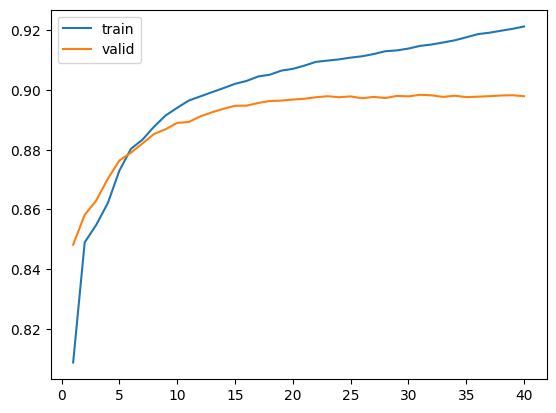

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(hist.history['accuracy']) + 1)
sns.lineplot(x=epoch_count,  y=hist.history['accuracy'], label='train')
sns.lineplot(x=epoch_count,  y=hist.history['val_accuracy'], label='valid')
plt.show()

### 5 - Inferencia
Experimentar el funcionamiento de su modelo. Recuerde que debe realizar la inferencia de los modelos por separado de encoder y decoder.

In [ ]:
# Armar los conversores de índice a palabra:
idx2word_input = {v:k for k, v in word2idx_inputs.items()}
idx2word_target = {v:k for k, v in word2idx_outputs.items()}


In [ ]:
def generate_response(input_seq):
    # Se transforma la sequencia de entrada a los estados "h" y "c" de la LSTM
    # para enviar la primera vez al decoder
    states_value = encoder_model.predict(input_seq)

    # Se inicializa la secuencia de entrada al decoder como "<sos>"
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']

    # Se obtiene el índice que finaliza la inferencia
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        # Predicción del próximo elemento
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value)
        idx = np.argmax(output_tokens[0, 0, :])

        # Si es "end of sentece <eos>" se acaba
        if eos == idx:
            break

        # Transformar idx a palabra
        word = ''
        if idx > 0:
            word = idx2word_target[idx]
            output_sentence.append(word)

        # Actualizar los estados dada la última predicción
        states_value = [h, c]

        # Actualizar secuencia de entrada con la salida (re-alimentación)
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)

In [ ]:
def beam_search_decode(input_seq, encoder_model, decoder_model, word2idx_outputs, idx2word_target, max_out_len, beam_width):
    # Obtener el estado inicial del encoder
    states_value = encoder_model.predict(input_seq, verbose=0)

    # <sos> token
    sos_token_id = word2idx_outputs['<sos>']
    eos_token_id = word2idx_outputs['<eos>']

    # Lista de tuplas (score, sequence, states)
    # score: log probability acumulada
    # sequence: lista de ids de palabras
    # states: estados LSTM (h, c)
    initial_beam = [(0.0, [sos_token_id], states_value)]
    beams = initial_beam

    final_sequences = [] # Para almacenar secuencias completas (con <eos>)

    for _ in range(max_out_len):
        all_candidates = []
        for score, current_sequence, current_states in beams:
            last_token = current_sequence[-1]

            # Si ya se encontró el token EOS en una secuencia, la añadimos a las finalizadas
            # y no la expandimos más.
            if last_token == eos_token_id:
                final_sequences.append((score, current_sequence))
                continue

            # Preparar la entrada del decoder para el próximo token
            target_seq = np.zeros((1, 1))
            target_seq[0, 0] = last_token

            # Predecir el siguiente token y los nuevos estados
            output_tokens, h, c = decoder_model.predict([target_seq] + current_states, verbose=0)

            # Obtener las probabilidades (log probabilities para evitar underflow)
            log_probs = np.log(output_tokens[0, -1, :]) # El último -1 selecciona la distribución de probabilidad para el token actual

            # Obtener los top 'beam_width' candidatos para el siguiente token
            top_k_indices = log_probs.argsort()[-beam_width:][::-1]

            for idx in top_k_indices:
                new_score = score + log_probs[idx]
                new_sequence = current_sequence + [idx]
                new_states = [h, c]
                all_candidates.append((new_score, new_sequence, new_states))

        # Ordenar todos los candidatos y seleccionar los top 'beam_width'
        # Priorizamos secuencias más largas con un buen score si ya tienen EOS
        # O si no, simplemente ordenamos por score.
        beams = sorted(all_candidates, key=lambda x: x[0], reverse=True)[:beam_width]

        # Si todas las secuencias en los beams han alcanzado EOS, podemos parar antes
        if not any(seq[-1] != eos_token_id for _, seq, _ in beams):
            break

    # Si no se encontraron secuencias finalizadas, tomamos la mejor del último paso
    if not final_sequences:
        # Limpiar el <sos> y <eos> si están presentes
        best_seq_ids = beams[0][1]
    else:
        # O la mejor de las secuencias finalizadas
        best_seq_ids = sorted(final_sequences, key=lambda x: x[0], reverse=True)[0][1]

    # Asegurarse de quitar <sos> y <eos> para la salida final
    cleaned_sequence = [token_id for token_id in best_seq_ids if token_id != sos_token_id and token_id != eos_token_id]

    return ' '.join([idx2word_target[idx] for idx in cleaned_sequence if idx in idx2word_target])

def stochastic_beam_search_decode(input_seq, encoder_model, decoder_model, word2idx_outputs, idx2word_target, max_out_len, beam_width, temperature=1.0):
    states_value = encoder_model.predict(input_seq, verbose=0)

    sos_token_id = word2idx_outputs['<sos>']
    eos_token_id = word2idx_outputs['<eos>']

    # (score, sequence, states)
    initial_beam = [(0.0, [sos_token_id], states_value)]
    beams = initial_beam

    final_sequences = []

    for _ in range(max_out_len):
        all_candidates = []
        for score, current_sequence, current_states in beams:
            last_token = current_sequence[-1]

            if last_token == eos_token_id:
                final_sequences.append((score, current_sequence))
                continue

            target_seq = np.zeros((1, 1))
            target_seq[0, 0] = last_token

            output_tokens, h, c = decoder_model.predict([target_seq] + current_states, verbose=0)

            # Aplicar temperatura y softmax para muestreo
            probs = output_tokens[0, -1, :] # Probabilidades directas (sin log)
            probs = np.exp(np.log(probs) / temperature) # Aplicar temperatura
            probs = probs / np.sum(probs) # Normalizar de nuevo para que sumen 1

            # Muestrear 'beam_width' candidatos del vocabulario
            # np.random.choice puede fallar si las probabilidades son muy pequeñas y suman 0 o 1 exactamente,
            # o si hay NaNs debido a log(0). Añadimos un chequeo para ello.
            if np.sum(probs) == 0 or np.any(np.isnan(probs)):
                # Si hay problemas, volvemos a decodificación greedy solo para este paso o seleccionamos los top k directamente
                top_k_indices = np.argsort(output_tokens[0, -1, :])[-beam_width:][::-1]
                sampled_indices = top_k_indices
            else:
                try:
                    sampled_indices = np.random.choice(len(probs), size=beam_width, p=probs, replace=False)
                except ValueError:
                    # Si np.random.choice falla (ej. p no suma 1, o size > num_words_output)
                    # Simplemente toma los top_k_indices
                    top_k_indices = np.argsort(output_tokens[0, -1, :])[-beam_width:][::-1]
                    sampled_indices = top_k_indices

            for idx in sampled_indices:
                # Recalcular el score usando la probabilidad original (sin temperatura) para la evaluación
                # o usar la probabilidad ajustada por temperatura si se desea que el score refleje la 'aleatoriedad'
                # Aquí, usaremos la probabilidad original para el score.
                original_prob = output_tokens[0, -1, idx]
                if original_prob == 0:
                    new_score = -np.inf # Evitar log(0)
                else:
                    new_score = score + np.log(original_prob)

                new_sequence = current_sequence + [idx]
                new_states = [h, c]
                all_candidates.append((new_score, new_sequence, new_states))

        # Asegurarse de que all_candidates no esté vacío antes de ordenar
        if not all_candidates:
            break

        beams = sorted(all_candidates, key=lambda x: x[0], reverse=True)[:beam_width]

        if not any(seq[-1] != eos_token_id for _, seq, _ in beams):
            break

    if not final_sequences:
        best_seq_ids = beams[0][1]
    else:
        best_seq_ids = sorted(final_sequences, key=lambda x: x[0], reverse=True)[0][1]

    cleaned_sequence = [token_id for token_id in best_seq_ids if token_id != sos_token_id and token_id != eos_token_id]

    return ' '.join([idx2word_target[idx] for idx in cleaned_sequence if idx in idx2word_target])

In [ ]:
questions = [
    "hello",
    "can you help me?",
    "I want to know the weather",
    "where are you from?",
    "do you like animals?",
    "what is your favorite game?",
    "do you like movies?"
]

results = []
beam_width = 3

for q_text in questions:
    # Clean and tokenize the input question
    clean_q_text = clean_text(q_text)
    integer_seq_test = input_tokenizer.texts_to_sequences([clean_q_text])[0]
    encoder_sequence_test = pad_sequences([integer_seq_test], maxlen=max_input_len)

    # Get the model's response using greedy decoding
    response_greedy = generate_response(encoder_sequence_test)

    # Get the model's response using deterministic beam search
    response_beam = beam_search_decode(
        encoder_sequence_test, encoder_model, decoder_model,
        word2idx_outputs, idx2word_target, max_out_len, beam_width
    )

    # Get the model's response using stochastic beam search with temperature 0.5
    response_stochastic_05 = stochastic_beam_search_decode(
        encoder_sequence_test, encoder_model, decoder_model,
        word2idx_outputs, idx2word_target, max_out_len, beam_width, temperature=0.5
    )

    # Get the model's response using stochastic beam search with temperature 2
    response_stochastic_2 = stochastic_beam_search_decode(
        encoder_sequence_test, encoder_model, decoder_model,
        word2idx_outputs, idx2word_target, max_out_len, beam_width, temperature=2
    )

    results.append({"Question": q_text,
                    "Greedy Response": response_greedy,
                    "Beam Search (Det)": response_beam,
                    "Beam Search (Stoch T=0.5)": response_stochastic_05,
                    "Beam Search (Stoch T=2)": response_stochastic_2})

response_df = pd.DataFrame(results)
display(response_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━

,Question,Greedy Response,Beam Search (Det),Beam Search (Stoch T=0.5),Beam Search (Stoch T=2)
0,hello,hello how are you,hello how are you,hello how are you,hii
1,can you help me?,what do you do for a living,what do you do for a living,what do you do for a living,tnx
2,I want to know the weather,what do you do for a living,what do you do for a living,what do you do for a living,hahaha
3,where are you from?,i am from california how about you,i am from california how about you,india,where
4,do you like animals?,i do not like it,i do not like it,i do not like it,everything
5,what is your favorite game?,i like to play video games,cricket,i like to play video games,quite mouse kind of dog
6,do you like movies?,i do not have a lot of time for that,i do not like it,i do not like it,no


## Conclusiones

Durante el proceso de experimentación y mejora del modelo, se han notado los siguientes puntos clave:

-   Se observó una mejora sustancial al utilizar embeddings de **300 dimensiones** en lugar de los de 50 dimensiones que se proporcionaban en el ejemplo inicial.
-   Inicialmente, para optimizar el uso de la memoria RAM, se emplearon `batch_size` de 16 para el entrenamiento, lo cual resultó en un empeoramiento significativo de los resultados finales.
-   Las pruebas para aumentar las capas de la red hasta 1024 unidades no mostraron una mejora sustancial notable en el rendimiento del modelo.
-   El uso de la función de pérdida `categorical_crossentropy` demostró una mejora en la respuesta del modelo en comparación con `sparse_categorical_crossentropy`.
-   Las mejoras más notables en cuanto a la comprensión y calidad de la respuesta se lograron al **aumentar el `batch_size`**, incrementar las épocas de entrenamiento (de 15 a 40), y ajustar el `dropout`.
-   En algunas iteraciones, la presencia del `EarlyStopping` también llevó a una pérdida de calidad en la respuesta, sugiriendo que en ciertos escenarios puede detener el entrenamiento prematuramente.
- el resultado mas optimo obtenido fue con batch size de 64, sin la funcion de Early Stopping y con un dropout de 0.2. Estos resultados fueron mejores incluso qe con un batch size de 128 y un dropout de 0.3, en esta configuracion las respuestas fueron muy estandar repitiendose en todas las estrategias de generación lo que indicaria un overfitting generado por el batche de 128 que no se regulariza con el 0.1 extra de dropout.
- En cuanto a las estrategias de generación, los mejores resultados se presentan con el  beam search deterministico. Mientras que los peores los da la temperatura de 0.5. Aunque la Temperatura de 2 pareceria estar generando respuestas muy flojas también. Lo que nos indica que , para este corpus y configuración de modelo, aplanar la campana para darle mas creatividad no resulto positivo.